# Phase 4 CRISP-DM — Modeling: Customer RFM Segmentation
**Project:** Customer Behavior Analysis — Olist Brazilian E-Commerce
**Goal:** Segment the customer base using the RFM model (Recency, Frequency, Monetary)
to identify actionable groups: Champions, Loyal, At Risk, Lost and New Customers.

**Why RFM?** It's the standard e-commerce segmentation framework: interpretable,
based on real behavior and directly actionable by marketing and retention teams.

**Data source:** `data/olist_master.csv` (Phase 3)

---


## 0. Imports and configuration

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path().resolve().parent
CSV  = ROOT / "data" / "olist_master.csv"
DASH = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.2f}".format)

print(f"CSV: data/{CSV.name}  ->  exists: {CSV.exists()}")

CSV: data/olist_master.csv  ->  exists: True


---
## 1. Data loading and reference date
The reference date (`snapshot_date`) is the day after the dataset's last order.
This simulates the viewpoint of an analyst running the analysis at the close of the period.

In [2]:
df = pd.read_csv(CSV, parse_dates=["order_purchase_timestamp"])

# Reference date: one day after the last order
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print(f"Orders loaded:     {len(df):,}")
print(f"Unique customers:  {df['customer_unique_id'].nunique():,}")
print(f"First order:       {df['order_purchase_timestamp'].min().date()}")
print(f"Last order:        {df['order_purchase_timestamp'].max().date()}")
print(f"Snapshot date:     {snapshot_date.date()}")

Orders loaded:     96,457
Unique customers:  93,337
First order:       2016-09-15
Last order:        2018-08-29
Snapshot date:     2018-08-30


---
## 2. Computing RFM metrics
For each `customer_unique_id` we compute:

| Metric | Definition | Interpretation |
|---------|-----------|----------------|
| **R** (Recency) | Days from the last purchase to `snapshot_date` | Lower = more recent = better |
| **F** (Frequency) | Number of unique orders | Higher = more loyal = better |
| **M** (Monetary) | Sum of `price_total` across all their orders | Higher = more valuable = better |

In [3]:
rfm = (
    df.groupby("customer_unique_id", as_index=False)
    .agg(
        last_purchase  =("order_purchase_timestamp", "max"),
        frequency      =("order_id",                 "nunique"),
        monetary       =("price_total",               "sum"),
    )
)

# Recency: days from the last purchase to snapshot_date
rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days
rfm = rfm.drop(columns="last_purchase")

print(f"Customers in RFM table: {len(rfm):,}")
print(f"\nFrequency distribution:")
print(rfm["frequency"].value_counts().sort_index().head(8).to_string())
print(f"\nRFM statistics:")
display(rfm[["recency", "frequency", "monetary"]].describe().round(1))

Customers in RFM table: 93,337

Frequency distribution:
frequency
1    90536
2     2573
3      181
4       28
5        9
6        5
7        3
9        1

RFM statistics:


,recency,frequency,monetary
count,93337.00,93337.00,93337.00
mean,237.90,1.00,141.60
std,152.60,0.20,215.70
min,1.00,1.00,0.80
25%,114.00,1.00,47.60
50%,219.00,1.00,89.70
75%,346.00,1.00,154.70
max,714.00,15.00,13440.00


---
## 3. Scoring: quintiles for R/M, business cuts for F
**Critical fix (portfolio review, priority 1 -- the most serious one found in this
project's audit):** an earlier version of this notebook used `rank(method='first')` +
`qcut(q=5)` for all three metrics alike. Frequency has **97.0%** of customers with
`frequency=1` (verified below), so the first 4 quintiles of F fell ENTIRELY within that tie, and
`rank(method='first')` broke the tie by **row order** after the `groupby` -- essentially the
alphabetical order of the `customer_unique_id` hash, not real behavior. Verifiable consequence:
every customer with F_score 1-4 had *exactly* 1 order, so segments like "Loyal"/"At Risk" (defined
by F≥3) ended up decided by noise for 97% of the base -- and in fact "At Risk" and "Lost" turned
out statistically indistinguishable from each other (same average recency, same average M_score
~3.0 across ALL segments: the signature of a random assignment).

**Solution:** F_score is now defined with **explicit business cuts** instead of automatic
quintiles, reflecting the real distribution (90,536 customers with F=1, 2,573 with F=2, 228 with
F≥3 -- see the value_counts in Section 2):
- `frequency == 1` -> `F_score = 1` (a single order: the vast majority of the base)
- `frequency == 2` -> `F_score = 3` (has repeated once)
- `frequency >= 3` -> `F_score = 5` (genuine repeat purchasing, a real minority)

This gives only 3 F levels instead of 5 -- **honest given that the data doesn't support finer
resolution** -- and removes the arbitrary tiebreak: no customer's F_score now depends on a table's
row order. R_score and M_score keep quintile scoring (both metrics do have real continuous
variance).

In [4]:
def quintile_score(series: pd.Series, ascending: bool = True) -> pd.Series:
    """Assigns a 1-5 score by quintiles. ascending=True -> high value = high score."""
    ranked = series.rank(method="first", ascending=ascending)
    return pd.qcut(ranked, q=5, labels=[1, 2, 3, 4, 5]).astype(int)

def frequency_score(freq: pd.Series) -> pd.Series:
    """Business cuts (not quintiles): F=1 -> 1, F=2 -> 3, F>=3 -> 5.
    See the Section 3 note on why an automatic quintile is not defensible here."""
    return pd.cut(freq, bins=[0, 1, 2, freq.max()], labels=[1, 3, 5], include_lowest=True).astype(int)

# R: inverse recency (fewer days = more recent = better = score 5)
rfm["R_score"] = quintile_score(rfm["recency"],   ascending=False)  # inverted
rfm["F_score"] = frequency_score(rfm["frequency"])
rfm["M_score"] = quintile_score(rfm["monetary"],  ascending=True)

# Composite score: mean of the three scores (1-5 scale)
rfm["RFM_score"] = (rfm[["R_score", "F_score", "M_score"]].mean(axis=1)).round(2)

# Concatenated string for segment lookup
rfm["RFM_string"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

print("R_score distribution:")
print(rfm["R_score"].value_counts().sort_index().to_string())
print("\nF_score distribution (business cuts, not quintiles):")
print(rfm["F_score"].value_counts().sort_index().to_string())
print(f"  -> {(rfm['F_score']==1).sum():,} customers with F_score=1 have exactly 1 order "
      f"({(rfm['F_score']==1).mean():.1%} of the base)")
print("\nFirst rows:")
display(rfm.head(5))

R_score distribution:
R_score
1    18668
2    18667
3    18667
4    18667
5    18668

F_score distribution (business cuts, not quintiles):
F_score
1    90536
3     2573
5      228
  -> 90,536 customers with F_score=1 have exactly 1 order (97.0% of the base)

First rows:


,customer_unique_id,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,RFM_string
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,112,4,1,4,3.00,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,115,4,1,1,2.00,411
2,0000f46a3911fa3c0805444483337064,1,69.00,537,1,1,2,1.33,112
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,321,2,1,1,1.33,211
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,288,2,1,5,2.67,215


### 3.1 Verification: is there still a random-assignment signature?
Direct check that the fix worked: if F_score still failed to discriminate, the average M_score
would be ~3.0 across all F groups (as before). We compare average M_score by F_score.

In [5]:
check_m_by_f = rfm.groupby("F_score")["M_score"].agg(["mean", "std", "count"]).round(3)
print("Average M_score by F_score (if the fix worked, these should NOT be ~3.0 and indistinguishable):")
display(check_m_by_f)

Average M_score by F_score (if the fix worked, these should NOT be ~3.0 and indistinguishable):


,mean,std,count
F_score,,,
1,2.96,1.41,90536
3,4.11,1.07,2573
5,4.58,0.83,228


---
## 4. Segment assignment
We define 5 segments based on thresholds of R_score, F_score and M_score:

| Segment | Rule | Business description |
|----------|-------|------------------------|
| **Champions** | R≥4, F≥4 | Bought recently and with high frequency |
| **Loyal** | F≥3, R≥3 (not Champions) | Frequent and recent, but not top-tier |
| **New Customers** | R≥4, F=1 | Recent first purchase — yet to be retained |
| **At Risk** | R≤2, F≥3 | Used to be frequent but haven't bought in a while |
| **Lost** | R≤2, F≤2 | Low frequency and a long time since purchasing |

In [6]:
def assign_segment(row: pd.Series) -> str:
    r, f = row["R_score"], row["F_score"]
    if r >= 4 and f >= 4:
        return "Champions"
    if f >= 3 and r >= 3:
        return "Loyal"
    if r >= 4 and f == 1:
        return "New Customers"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r <= 2 and f <= 2:
        return "Lost"
    return "Others"  # residual segment for intermediate combinations

rfm["segment"] = rfm.apply(assign_segment, axis=1)

seg_counts = rfm["segment"].value_counts()
print("Customers by segment:")
print(seg_counts.to_string())
print(f"\nTotal classified: {len(rfm):,}  |  Segments: {rfm['segment'].nunique()}")

Customers by segment:
segment
Lost             36344
New Customers    36132
Others           18060
Loyal             1689
At Risk            991
Champions          121

Total classified: 93,337  |  Segments: 6


---
## 5. Summary table by segment
We compute the key metrics per segment to understand each group's profile.

In [7]:
seg_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        n_customers      =("customer_unique_id", "count"),
        pct_customers    =("customer_unique_id", lambda x: len(x) / len(rfm) * 100),
        avg_recency_days =("recency",            "mean"),
        avg_frequency    =("frequency",           "mean"),
        avg_monetary     =("monetary",            "mean"),
        total_revenue    =("monetary",            "sum"),
        pct_revenue      =("monetary",            lambda x: x.sum() / rfm["monetary"].sum() * 100),
    )
    .sort_values("avg_monetary", ascending=False)
)

seg_summary = seg_summary.round({
    "pct_customers": 1, "avg_recency_days": 0, "avg_frequency": 2,
    "avg_monetary": 1, "total_revenue": 0, "pct_revenue": 1,
})

display(seg_summary.set_index("segment"))
seg_summary.to_csv(ROOT / "data" / "rfm_segments.csv", index=False)
print("\nTable saved to data/rfm_segments.csv")

,n_customers,pct_customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue,pct_revenue
segment,,,,,,,
Champions,121,0.10,89.00,3.51,461.50,55843.00,0.40
Loyal,1689,1.80,135.00,2.03,253.50,428207.00,3.20
At Risk,991,1.10,382.00,2.08,246.60,244358.00,1.80
New Customers,36132,38.70,90.00,1.00,140.30,5069448.00,38.40
Lost,36344,38.90,395.00,1.00,139.60,5074720.00,38.40
Others,18060,19.30,220.00,1.00,129.90,2345775.00,17.70



Table saved to data/rfm_segments.csv


---
## 6. Visualizations

### 6.1 RFM scatter plot: Recency vs Monetary colored by segment
Each point is a customer. Point size represents Frequency.
This visualization is the equivalent of the treemap in a continuous 2D space.

C:\Users\pardo\AppData\Local\Temp\ipykernel_7396\3516756852.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_per_seg = rfm.groupby("segment", group_keys=False).apply(


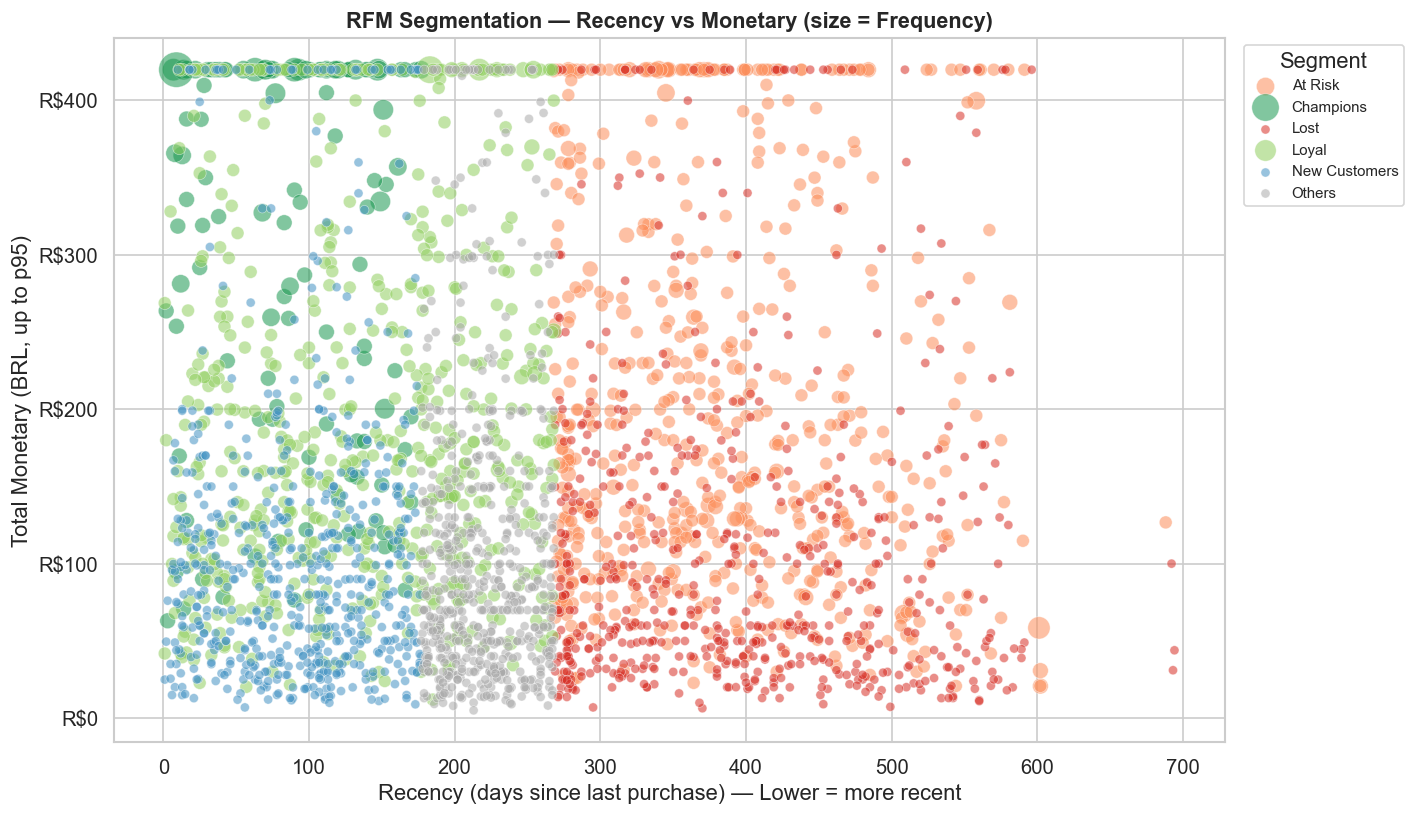

In [8]:
# Color palette per segment
SEG_COLORS = {
    "Champions":     "#1a9850",
    "Loyal":         "#91cf60",
    "New Customers": "#4393c3",
    "At Risk":       "#fc8d59",
    "Lost":          "#d73027",
    "Others":        "#aaaaaa",
}

# Stratified sample to avoid saturating the plot
sample_per_seg = rfm.groupby("segment", group_keys=False).apply(
    lambda g: g.sample(min(len(g), 600), random_state=42)
)

# Clip monetary at p95 for visualization
p95_m = rfm["monetary"].quantile(0.95)
sample_plot = sample_per_seg.copy()
sample_plot["monetary_clipped"] = sample_plot["monetary"].clip(upper=p95_m)

fig, ax = plt.subplots(figsize=(12, 7))

for seg, grp in sample_plot.groupby("segment"):
    ax.scatter(
        grp["recency"],
        grp["monetary_clipped"],
        s=grp["frequency"] * 30,        # size proportional to frequency
        c=SEG_COLORS.get(seg, "gray"),
        alpha=0.55, edgecolors="white", linewidths=0.4,
        label=seg, rasterized=True,
    )

ax.set_title("RFM Segmentation — Recency vs Monetary (size = Frequency)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Recency (days since last purchase) — Lower = more recent")
ax.set_ylabel("Total Monetary (BRL, up to p95)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax.legend(title="Segment", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(DASH / "rfm_scatter.png", bbox_inches="tight")
plt.show()

### 6.2 Customer and revenue distribution by segment (dual bar chart)
Compares each segment's weight in number of customers vs. revenue generated.
If Champions are few but generate a lot of revenue, they are a retention priority.

C:\Users\pardo\AppData\Local\Temp\ipykernel_7396\2386417931.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(seg_order, rotation=15, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_7396\2386417931.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(seg_order, rotation=15, ha="right")


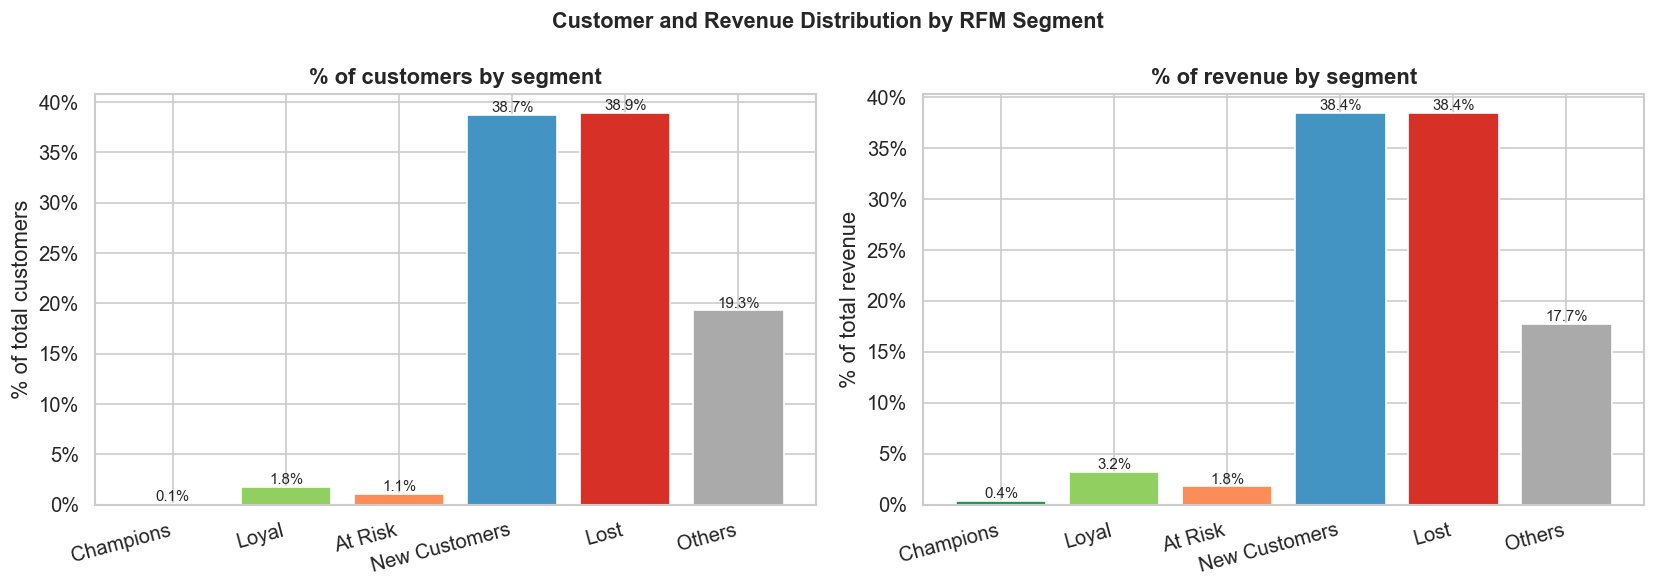

In [9]:
seg_order = seg_summary.sort_values("avg_monetary", ascending=False)["segment"].tolist()
seg_display = seg_summary.set_index("segment").loc[seg_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- % customers --
colors_bar = [SEG_COLORS.get(s, "gray") for s in seg_order]
axes[0].bar(seg_order, seg_display["pct_customers"], color=colors_bar, edgecolor="white")
for i, (seg, row) in enumerate(seg_display.iterrows()):
    axes[0].text(i, row["pct_customers"] + 0.3, f"{row['pct_customers']:.1f}%",
                 ha="center", fontsize=9)
axes[0].set_title("% of customers by segment", fontweight="bold")
axes[0].set_ylabel("% of total customers")
axes[0].set_xticklabels(seg_order, rotation=15, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# -- % revenue --
axes[1].bar(seg_order, seg_display["pct_revenue"], color=colors_bar, edgecolor="white")
for i, (seg, row) in enumerate(seg_display.iterrows()):
    axes[1].text(i, row["pct_revenue"] + 0.3, f"{row['pct_revenue']:.1f}%",
                 ha="center", fontsize=9)
axes[1].set_title("% of revenue by segment", fontweight="bold")
axes[1].set_ylabel("% of total revenue")
axes[1].set_xticklabels(seg_order, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Customer and Revenue Distribution by RFM Segment",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "rfm_distribution.png", bbox_inches="tight")
plt.show()

### 6.3 Heatmap of average scores by segment
Shows the average R, F, M profile for each segment.
Validates that the segmentation is coherent: Champions should have all three scores high.

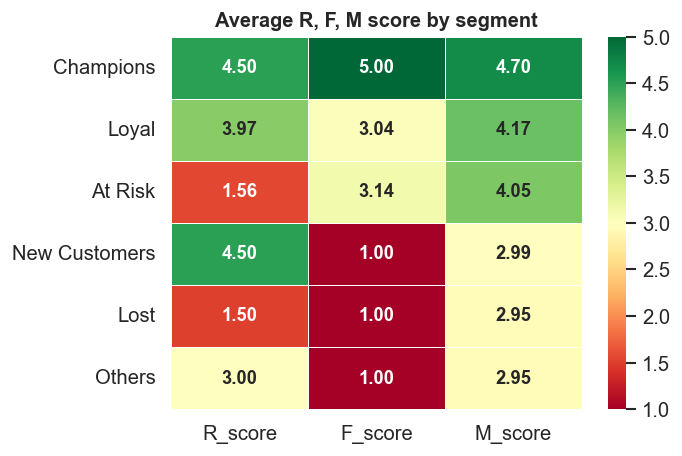

Average scores by segment:


,R_score,F_score,M_score
segment,,,
Champions,4.50,5.00,4.70
Loyal,3.97,3.04,4.17
At Risk,1.56,3.14,4.05
New Customers,4.50,1.00,2.99
Lost,1.50,1.00,2.95
Others,3.00,1.00,2.95


In [10]:
score_heatmap = (
    rfm.groupby("segment")[["R_score", "F_score", "M_score"]]
    .mean()
    .round(2)
    .loc[seg_order]  # ordered by descending monetary value
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    score_heatmap,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=1, vmax=5,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 11, "weight": "bold"},
)
ax.set_title("Average R, F, M score by segment", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(DASH / "rfm_heatmap_segments.png", bbox_inches="tight")
plt.show()

print("Average scores by segment:")
display(score_heatmap)

### 6.4 Distribution of Recency and Monetary by segment (violin plots)

C:\Users\pardo\AppData\Local\Temp\ipykernel_7396\3340545363.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\pardo\AppData\Local\Temp\ipykernel_7396\3340545363.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(seg_violin_order, rotation=15, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_7396\3340545363.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\pardo\AppData\Local\Temp\ipykernel_7396\3340545363.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(seg_violin_order, rotation=15, ha="right")


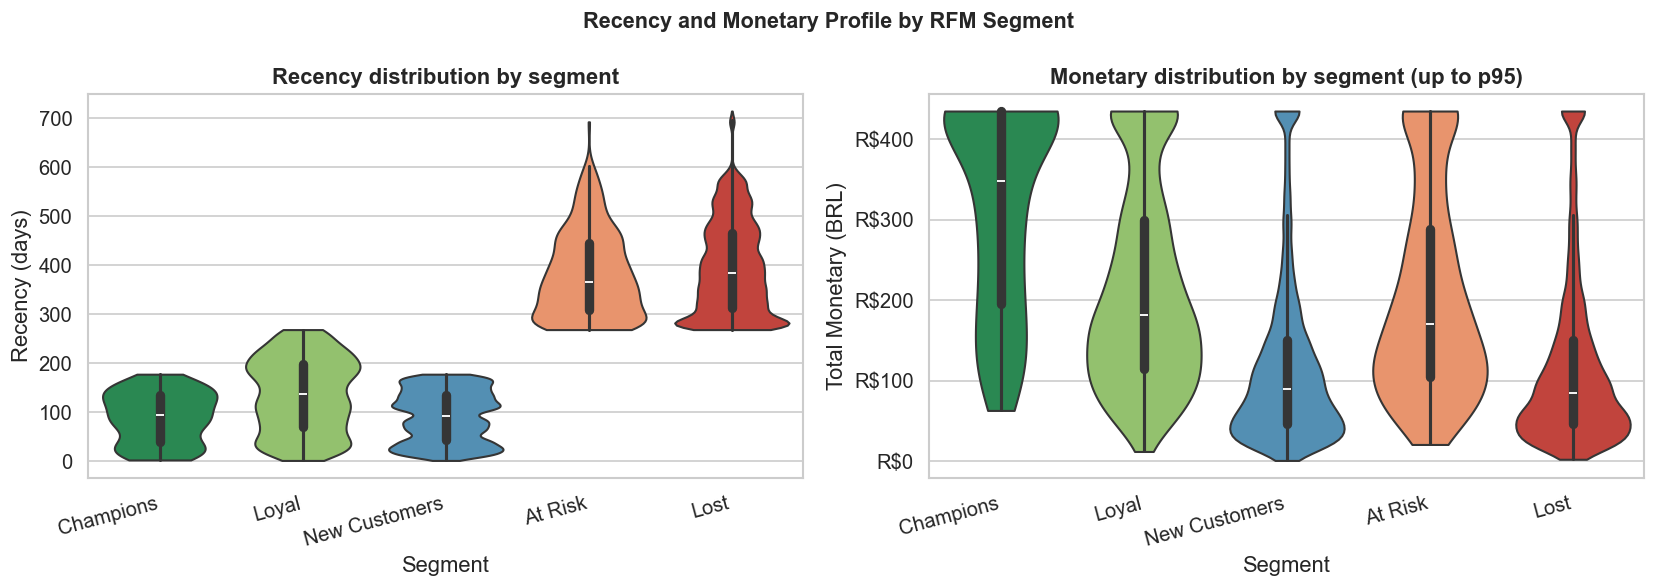

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order for violins: from best to worst segment
rfm_plot = rfm[rfm["segment"] != "Others"].copy()
rfm_plot["monetary_clipped"] = rfm_plot["monetary"].clip(upper=rfm_plot["monetary"].quantile(0.95))

seg_palette = {s: SEG_COLORS[s] for s in SEG_COLORS if s != "Others"}
seg_violin_order = ["Champions", "Loyal", "New Customers", "At Risk", "Lost"]

sns.violinplot(
    data=rfm_plot, x="segment", y="recency",
    order=seg_violin_order, palette=seg_palette,
    ax=axes[0], inner="box", cut=0,
)
axes[0].set_title("Recency distribution by segment", fontweight="bold")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Recency (days)")
axes[0].set_xticklabels(seg_violin_order, rotation=15, ha="right")

sns.violinplot(
    data=rfm_plot, x="segment", y="monetary_clipped",
    order=seg_violin_order, palette=seg_palette,
    ax=axes[1], inner="box", cut=0,
)
axes[1].set_title("Monetary distribution by segment (up to p95)", fontweight="bold")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Total Monetary (BRL)")
axes[1].set_xticklabels(seg_violin_order, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

plt.suptitle("Recency and Monetary Profile by RFM Segment",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "rfm_violin.png", bbox_inches="tight")
plt.show()

---
## 7. Export full RFM table
We save the RFM table with scores and segments for use in the evaluation notebook.

In [12]:
rfm_out = ROOT / "data" / "olist_rfm.csv"
rfm.to_csv(rfm_out, index=False)

size_mb = rfm_out.stat().st_size / 1024 / 1024
print(f"Exported:  data/{rfm_out.name}")
print(f"Size:      {size_mb:.2f} MB")
print(f"Rows:      {len(rfm):,}")
print(f"Columns:   {list(rfm.columns)}")

Exported:  data/olist_rfm.csv
Size:      6.16 MB
Rows:      93,337
Columns:   ['customer_unique_id', 'frequency', 'monetary', 'recency', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_string', 'segment']


---
## 8. Executive summary — RFM Segmentation

### Key findings

In [13]:
champs  = seg_summary[seg_summary["segment"] == "Champions"].iloc[0] if "Champions" in seg_summary["segment"].values else None
lost    = seg_summary[seg_summary["segment"] == "Lost"].iloc[0]      if "Lost"       in seg_summary["segment"].values else None
at_risk = seg_summary[seg_summary["segment"] == "At Risk"].iloc[0]   if "At Risk"    in seg_summary["segment"].values else None
new_c   = seg_summary[seg_summary["segment"] == "New Customers"].iloc[0] if "New Customers" in seg_summary["segment"].values else None

print("=" * 65)
print("EXECUTIVE SUMMARY — RFM SEGMENTATION")
print("=" * 65)
print(f"\nTotal customers analyzed: {len(rfm):,}")
print(f"\n{'Segment':<16} {'Customers':>9} {'% customers':>12} {'% revenue':>10} {'Avg monetary':>13}")
print("-" * 65)
for _, row in seg_summary.iterrows():
    print(f"{row['segment']:<16} {int(row['n_customers']):>9,} {row['pct_customers']:>11.1f}% {row['pct_revenue']:>9.1f}% {row['avg_monetary']:>12.0f} BRL")

print("\n" + "=" * 65)
print("RECOMMENDED ACTIONS BY SEGMENT")
print("=" * 65)
actions = {
    "Champions":     "VIP loyalty program, early access to new products, referrals",
    "Loyal":         "Upsell to premium categories, volume discounts, NPS surveys",
    "New Customers": "Onboarding email sequence, discount on second order, recommendations",
    "At Risk":       "Urgent reactivation campaign: time-limited coupon, win-back email",
    "Lost":          "Low-cost reactivation campaign or removal from the marketing list",
    "Others":        "Continuous monitoring; classify in the next RFM iteration",
}
for seg, action in actions.items():
    count = seg_counts.get(seg, 0)
    print(f"\n[{seg}] ({count:,} customers)")
    print(f"  -> {action}")

EXECUTIVE SUMMARY — RFM SEGMENTATION

Total customers analyzed: 93,337

Segment          Customers  % customers  % revenue  Avg monetary
-----------------------------------------------------------------
Champions              121         0.1%       0.4%          462 BRL
Loyal                1,689         1.8%       3.2%          254 BRL
At Risk                991         1.1%       1.8%          247 BRL
New Customers       36,132        38.7%      38.4%          140 BRL
Lost                36,344        38.9%      38.4%          140 BRL
Others              18,060        19.3%      17.7%          130 BRL

RECOMMENDED ACTIONS BY SEGMENT

[Champions] (121 customers)
  -> VIP loyalty program, early access to new products, referrals

[Loyal] (1,689 customers)
  -> Upsell to premium categories, volume discounts, NPS surveys

[New Customers] (36,132 customers)
  -> Onboarding email sequence, discount on second order, recommendations

[At Risk] (991 customers)
  -> Urgent reactivation campaign

---
## 9. Methodology summary

| Step | Decision | Reason |
|------|----------|--------|
| Reference date | `max_date + 1 day` | Simulates the analysis point at the dataset's close |
| Scoring scale (R, M) | Quintiles 1–5 | Robust to skewed distributions and outliers |
| Scoring scale (F) | Business cuts (1→1, 2→3, ≥3→5), not quintiles | 97.0% of customers have frequency=1: an automatic quintile ties almost the entire base, and the `rank(method='first')` tiebreak is essentially random (see Section 3 — priority-1 fix) |
| Segmentation | Rules based on R and F | F is the most CRM-actionable loyalty driver |
| `Others` category | Residual segment | Intermediate combinations that aren't directly actionable |

### Next steps — Phase 5 (Evaluation)
- Cross RFM segments with `is_negative_review` to check whether `At Risk` or `Lost` customers have a higher negative review rate
- Supervised predictive model for `is_negative_review` using `delivery_delay_days`, `freight_ratio` and `delivery_days`
- Final dashboard consolidating findings from all phases
